# Analysis of specific junction

We are exemplary considering junction CIRMBUYJFK_f__CWCCKOQCWZ_r

In [2]:
# set working directory to project folder
import sys, os, re
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import mplcursors

import altair as alt
from itertools import combinations
import numpy as np
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO, Align
from Bio.Align import AlignInfo
from Bio.motifs import Motif
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import plotly.io as pio
pio.renderers.default = "browser" 


from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, convert_gbk_fasta, convert_gbk_fasta_plasmids, extract_biosample_ids
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_combined, plot_junction_pangraph_interactive, plot_dendrogram, plot_hits_distribution, plot_event_length_distribution
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, find_consensus_paths_core
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.junction_trees import build_tree_from_block_list

from junction_analysis.annotate_insertions import load_all_deletions_summaries, load_all_insertions_summaries, load_all_translocations_summaries, load_all_inversions_summaries, collect_hits_info_counts, combine_NCBI_atb_results_centralized, collect_hits_info_counts_with_self, combine_all_junctions_summaries, deduplicate_events
from junction_analysis.annotate_insertions import write_insertions_fasta, get_insertions_deletions_from_consensus, retrieve_SAMids_txt, combine_NCBI_atb_results, summarize_deletions_consensus, find_insertion_hits_own_genome, find_insertion_hits_in_plasmids

In [2]:
example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

#aln_path = f"../results/block_alignments/{example_junction}/block_11400043001338627984_aln.fa"
#distance_matrix, Z, names = cluster_alignment(aln_path)
#clusters = retrieve_cluster_assignments(Z, names, n_clusters=2)

## Analyze deviations (insertions / deletions / translocations / inversions) from consensus path
First load all detected events

In [3]:
insertions_df = load_all_insertions_summaries("../results/atb_lookup/insertions", example_junction, save_df=False)
insertions_df

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx
0,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_OX030701.1,[6932368721519041699|-|1314867519434933921_1],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,760,-,38342,39102,1314867519434933921
1,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP021935.1,[517157241956952768|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1248,+,5281,6529,11445151531734952644
2,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP076693.1,[964531385716605116|+|]_[16982887268023976258|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1863,+,22045,23908,5100696243500885373
3,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP128947.1,[964531385716605116|+|]_[16982887268023976258|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1863,+,22045,23908,5100696243500885373
4,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP107114.1,[517157241956952768|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1248,+,7143,8391,13357752436170011985
5,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP107172.1,[517157241956952768|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1248,+,7144,8392,13357752436170011985
6,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP030337.1,[6932368721519041699|+|16056383497489254679_1],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,760,+,19392,20152,16056383497489254679
7,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP124429.1,[517157241956952768|-|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1248,-,4881,6129,5611279500882571565
8,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP018970.1,[6932368721519041699|-|17115477248436968411_1],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,767,-,51236,52003,17115477248436968411
9,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,NZ_CP019015.1,[16982887268023976258|-|]_[964531385716605116|-|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,1863,-,22044,23907,5100696243500885373


## Insertions

upload all fastas: ```scp -r /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/```
or 
```
rsync -av \
  --include='*/' \
  --include='*.fasta' \
  --exclude='*' \
  /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r/ \
  becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/CIRMBUYJFK_f__CWCCKOQCWZ_r/
```

run:  `bash run_all_lexicmap.sh ./queries/CIRMBUYJFK_f__CWCCKOQCWZ_r` on cluster to submit single jobs, can only be done for one junction

this now automatically creates id files and retrieve_SAMids_txt(parent_dir="../results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r") doesnt have to be run anymore

run NCBI lookup: ```sbatch collect_ids_and_fetch.sh ./queries/CIRMBUYJFK_f__CWCCKOQCWZ_r```

download results: 
```
rsync -av --include="*/" \
--include="*.lexicmap.tsv" \
--include="*ncbi_results.tsv" \
--exclude="*" \
becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/CIRMBUYJFK_f__CWCCKOQCWZ_r/ \
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r/
```

combine NCBI lookup with lexicmap hit dataframes:
run in notebook `combine_NCBI_atb_results(parent_dir="../results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r")`


## Insertions - All junctions

upload all fastas: 
```
rsync -av \
  --include='*/' \
  --include='*.fasta' \
  --exclude='*' \
  /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/ \
  becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/
```

run array job for many files `bash run_all_lexicmap_array.sh ./queries/` which then runs run_all_lexicmap_array.sh
rerun timeouted jobs, now with 60 min timelimit: `bash rerun_timeout_lexicmap.sh ./logs`

ncbi lookup on all junctions: `bash collect_and_fetch_array.sh ./queries/` (can take like 5 min to load all ids, I had 454831 unique ids) and then `bash merge_biosample_results.sh ./queries` to merge

download results: 
```
rsync -av --include="*/" \
--include="*.lexicmap.tsv" \
--include="*ncbi_results.tsv" \
--exclude="*" \
becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/ \
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/
```
final ncbi lookups are in `results/atb_lookup/insertions/all_ncbi_results.tsv`

run in notebook: `combine_NCBI_atb_results_centralized(parent_dir= "../results/atb_lookup/insertions")` to combine results (takes 12 min)


In [4]:
# hits within their own genome or plasmids are not foreign and should be excluded
st131_sam_df = extract_biosample_ids("../data/gbk", "../data/plasmids")
st131_sam_df

,isolate_id,accession,type,biosample
0,NC_022648.1,NC_022648.1,chromosome,SAMN02603887
1,NZ_AP018784.1,NZ_AP018784.1,chromosome,SAMD00127374
2,NZ_AP021998.1,NZ_AP021998.1,chromosome,SAMD00194413
3,NZ_AP022032.1,NZ_AP022032.1,chromosome,SAMD00194427
4,NZ_AP022044.1,NZ_AP022044.1,chromosome,SAMD00194451
...,...,...,...,...
804,NZ_OX637964.1,NZ_OX637965.1,plasmid,SAMEA112356747
805,NZ_OX637964.1,NZ_OX637966.1,plasmid,SAMEA112356747
806,NZ_OX637964.1,NZ_OX637967.1,plasmid,SAMEA112356747
807,NZ_OY019088.1,NZ_OY019089.1,plasmid,SAMEA112356746


In [5]:
summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=False)
summaries['insertions']

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx
0,ADIVNXMSJF_r__CGRLRHSCCE_f,consensus_1,NZ_CP103562.1,[10467811667185626553|+|],segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283,15264,12675429639006275041
1,ADOVFNSINA_f__ECOWCWQMQJ_f,consensus_1,NZ_CP116085.1,[2885183895822662185|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189,7966,12863862502596669040
2,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_CP107153.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941,12718,16305501466558477249
3,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_AP022044.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,6295978535415985145
4,AEJQYPEVQR_f__SQYOENFQOY_f,consensus_1,NZ_OX030701.1,[1233050476806559636|-|],segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,2793,3570,3579820473221573810
...,...,...,...,...,...,...,...,...,...,...,...
8082,YJSEGEHASG_r__YWSGZOAHNX_r,consensus_1,NZ_CP019012.1,[3886675241220391455|+|],segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,58257,60797,12716710876323799779
8083,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104846.1,[3870718793672684742|+|5120184519711206319_1],segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,60231,60999,5120184519711206319
8084,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104848.1,[2624032834068938794|+|]_[1528420688200569391|...,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,60231,180320,5120184519711206319
8085,YVEVUPDYEE_f__ZFYFAGFPQE_f,consensus_1,NZ_CP124436.1,[213612989930417787|+|],segment_0,../results/atb_lookup/insertions/YVEVUPDYEE_f_...,42512,+,8832,51344,2622873865824788133


In [6]:
"""
hits_df = collect_hits_info_counts_with_self(                                                                                                                                                             
      "../results/atb_lookup/insertions",                                                                                                                                        
      st131_sam_df,
      min_pident=100.0                                                                                                                                                                                    
  )
hits_df.to_csv("../results/atb_lookup/insertions/lexicmap_hits_summary_100.csv", index = False)

# 1 min
"""

'\nhits_df = collect_hits_info_counts_with_self(                                                                                                                                                             \n      "../results/atb_lookup/insertions",                                                                                                                                        \n      st131_sam_df,\n      min_pident=100.0                                                                                                                                                                                    \n  )\nhits_df.to_csv("../results/atb_lookup/insertions/lexicmap_hits_summary_100.csv", index = False)\n\n# 1 min\n'

In [7]:
"""
hits_df = pd.read_csv("../results/atb_lookup/insertions/lexicmap_hits_summary_100.csv")

hits_df['consensus'] = hits_df['consensus'].str.replace('consensus', 'consensus_', regex=False)                                                                                                           

hits_merged = summaries['insertions'].merge(                                                                                                                                                                   
      hits_df.rename(columns={"segment": "insertion"}),                                                                                                                                                     
      on=["junction_name", "consensus", "genome_name", "insertion"],                                                                                                                                        
      how="left"  
  )
hits_merged

hits_deduplicated_df = deduplicate_events({"insertions": hits_merged})
hits_deduplicated_df.to_csv("../results/atb_lookup/insertions/lexicmap_hits_deduplicated.csv")
"""

'\nhits_df = pd.read_csv("../results/atb_lookup/insertions/lexicmap_hits_summary_100.csv")\n\nhits_df[\'consensus\'] = hits_df[\'consensus\'].str.replace(\'consensus\', \'consensus_\', regex=False)                                                                                                           \n\nhits_merged = summaries[\'insertions\'].merge(                                                                                                                                                                   \n      hits_df.rename(columns={"segment": "insertion"}),                                                                                                                                                     \n      on=["junction_name", "consensus", "genome_name", "insertion"],                                                                                                                                        \n      how="left"  \n  )\nhits_merged\n\nhits_deduplicated_df = dedupl

In [8]:
hits_deduplicated_df = pd.read_csv("../results/atb_lookup/insertions/lexicmap_hits_deduplicated.csv")
hits_deduplicated_df = hits_deduplicated_df[hits_deduplicated_df['length']> 200]

In [58]:
hits_deduplicated_df

,Unnamed: 0,event_type,junction_name,path,ctx,consensus,insertion,fasta_path,length,strand,...,n_hits_Enterobacter,n_hits_Pantoea_brenneri,n_hits_Mixta_calida,n_hits_Serratia_sp.,n_hits_Bifidobacterium_choerinum,n_hits_Nissabacter_archeti,n_hits_Nosocomiicoccus_ampullae,n_hits_Candidatus_Pantoea,n_hits_Leclercia_sp.,n_hits_unclassified_Prevotella
0,0,insertion,ADIVNXMSJF_r__CGRLRHSCCE_f,[10467811667185626553|+|],12675429639006275041,consensus_1,segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,...,0,0,0,0,0,0,0,0,0,0
1,1,insertion,ADOVFNSINA_f__ECOWCWQMQJ_f,[2885183895822662185|+|],12863862502596669040,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,...,0,0,0,0,0,0,0,0,0,0
2,2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],6295978535415985145,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,...,0,0,0,0,0,0,0,0,0,0
3,3,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],16305501466558477249,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,...,0,0,0,0,0,0,0,0,0,0
4,4,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|+|],13278839926153538614,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,776,+,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1831,1831,insertion,XXVQEZNBQB_f__YMBQLXNBIS_f,[7798500702088635138|+|],7460938438515399510,consensus_2,segment_0,../results/atb_lookup/insertions/XXVQEZNBQB_f_...,1309,+,...,0,0,0,0,0,0,0,0,0,0
1832,1832,insertion,YJSEGEHASG_r__YWSGZOAHNX_r,[3886675241220391455|+|],12716710876323799779,consensus_1,segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,...,0,0,0,0,0,0,0,0,0,0
1833,1833,insertion,YUOECYBHUS_f__ZTHKZYHPIX_f,[2624032834068938794|+|]_[1528420688200569391|...,5120184519711206319,consensus_1,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,...,0,0,0,0,0,0,0,0,0,0
1834,1834,insertion,YUOECYBHUS_f__ZTHKZYHPIX_f,[3870718793672684742|+|5120184519711206319_1],5120184519711206319,consensus_1,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,...,0,0,0,0,0,0,0,0,0,0


In [57]:
hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] > 0]

,Unnamed: 0,event_type,junction_name,path,ctx,consensus,insertion,fasta_path,length,strand,...,n_hits_Enterobacter,n_hits_Pantoea_brenneri,n_hits_Mixta_calida,n_hits_Serratia_sp.,n_hits_Bifidobacterium_choerinum,n_hits_Nissabacter_archeti,n_hits_Nosocomiicoccus_ampullae,n_hits_Candidatus_Pantoea,n_hits_Leclercia_sp.,n_hits_unclassified_Prevotella
0,0,insertion,ADIVNXMSJF_r__CGRLRHSCCE_f,[10467811667185626553|+|],12675429639006275041,consensus_1,segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,...,0,0,0,0,0,0,0,0,0,0
1,1,insertion,ADOVFNSINA_f__ECOWCWQMQJ_f,[2885183895822662185|+|],12863862502596669040,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,...,0,0,0,0,0,0,0,0,0,0
3,3,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],16305501466558477249,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,...,0,0,0,0,0,0,0,0,0,0
4,4,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|+|],13278839926153538614,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,776,+,...,0,0,0,0,0,0,0,0,0,0
5,5,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|-|],3579820473221573810,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,1829,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[9391285909405162019|+|],10605139617336915684,consensus_3,segment_1,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,877,+,...,0,0,0,0,0,0,0,0,0,0
1830,1830,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[9474894503673110699|+|]_[3973231311631193246|...,15908320088543975006,consensus_3,segment_0,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,904,+,...,0,0,0,0,0,0,0,0,0,0
1832,1832,insertion,YJSEGEHASG_r__YWSGZOAHNX_r,[3886675241220391455|+|],12716710876323799779,consensus_1,segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,...,0,0,0,0,0,0,0,0,0,0
1834,1834,insertion,YUOECYBHUS_f__ZTHKZYHPIX_f,[3870718793672684742|+|5120184519711206319_1],5120184519711206319,consensus_1,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,...,0,0,0,0,0,0,0,0,0,0


In [9]:
species_cols = [c for c in hits_deduplicated_df.columns if c.startswith("n_hits_") and c not in
                  {"n_hits_own_chromosome", "n_hits_own_plasmid", "n_hits_other_chromosome",
                   "n_hits_other_plasmid", "n_hits_external"}]

species_totals = hits_deduplicated_df[species_cols].sum().reset_index()
species_totals.columns = ["species", "n_hits"]
species_totals["species"] = species_totals["species"].str.replace("n_hits_", "").str.replace("_", " ")
species_totals = species_totals.sort_values("n_hits", ascending=False).reset_index(drop=True)

In [59]:
species_totals

,species,n_hits
0,Escherichia coli,3445114
1,Salmonella enterica,425583
2,Shigella flexneri,212754
3,Klebsiella pneumoniae,208378
4,Shigella sonnei,22169
...,...,...
270,Klebsiella africana,1
271,Bifidobacterium adolescentis,1
272,unclassified Prevotella,1
273,Synechococcus elongatus,0


In [61]:
hits_deduplicated_df.majority_organism.value_counts().sum()

np.int64(1100)

In [12]:
# we only consider 100 % hits here

hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] == 0]

,Unnamed: 0,event_type,junction_name,path,ctx,consensus,insertion,fasta_path,length,strand,...,n_hits_Enterobacter,n_hits_Pantoea_brenneri,n_hits_Mixta_calida,n_hits_Serratia_sp.,n_hits_Bifidobacterium_choerinum,n_hits_Nissabacter_archeti,n_hits_Nosocomiicoccus_ampullae,n_hits_Candidatus_Pantoea,n_hits_Leclercia_sp.,n_hits_unclassified_Prevotella
2,2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],6295978535415985145,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,...,0,0,0,0,0,0,0,0,0,0
8,8,insertion,AFFODHUCNW_r__VRDEBAMMSO_r,[13690498838976304279|+|],18134582529277137450,consensus_1,segment_0,../results/atb_lookup/insertions/AFFODHUCNW_r_...,38347,+,...,0,0,0,0,0,0,0,0,0,0
9,9,insertion,AFFODHUCNW_r__VRDEBAMMSO_r,[15161573651151395308|+|],4011715611649092347,consensus_1,segment_0,../results/atb_lookup/insertions/AFFODHUCNW_r_...,11921,+,...,0,0,0,0,0,0,0,0,0,0
11,11,insertion,AFFODHUCNW_r__VRDEBAMMSO_r,[4011715611649092347|+|194907409757558235_2]_[...,194907409757558235_2,consensus_1,segment_0,../results/atb_lookup/insertions/AFFODHUCNW_r_...,11107,+,...,0,0,0,0,0,0,0,0,0,0
14,14,insertion,AHYRAMUUTM_f__OWNWVIRSZP_f,[10556920753591662767|+|],936206662838615623,consensus_1,segment_0,../results/atb_lookup/insertions/AHYRAMUUTM_f_...,8262,+,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1808,1808,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[8806849404149054843|+|]_[8730284033119029299|...,820162239835546973,consensus_7,segment_6,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,1833,+,...,0,0,0,0,0,0,0,0,0,0
1809,1809,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[8806849404149054843|+|]_[8730284033119029299|...,820162239835546973,consensus_7,segment_3,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,2009,+,...,0,0,0,0,0,0,0,0,0,0
1810,1810,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[8854941578893199967|+|],8153653727970554654,consensus_2,segment_3,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,212,+,...,0,0,0,0,0,0,0,0,0,0
1831,1831,insertion,XXVQEZNBQB_f__YMBQLXNBIS_f,[7798500702088635138|+|],7460938438515399510,consensus_2,segment_0,../results/atb_lookup/insertions/XXVQEZNBQB_f_...,1309,+,...,0,0,0,0,0,0,0,0,0,0


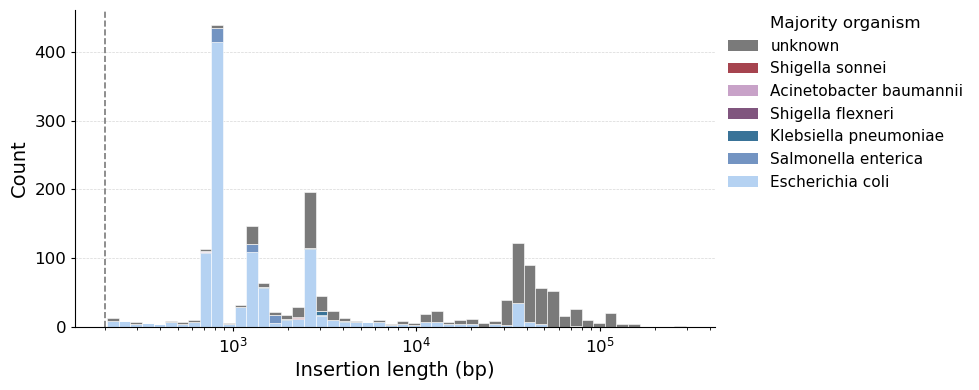

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Insertion length (bp)', ylabel='Count'>)

In [13]:
plot_event_length_distribution(
      hits_deduplicated_df,
      color_by_majority_organism=True,
      n_species = 6,
      log_x=True,
      log_y = False,
      figsize=(10,4)
  )

In [14]:
hits_deduplicated_df.majority_organism.value_counts()

majority_organism
Escherichia coli           1039
Salmonella enterica          46
Klebsiella pneumoniae        11
Shigella flexneri             2
Acinetobacter baumannii       1
Shigella sonnei               1
Name: count, dtype: int64

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2713: RuntimeWarning:

invalid value encountered in divide

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2713: RuntimeWarning:

invalid value encountered in divide



Saved figure to ../figures/species_assignments_length.pdf


(<Figure size 700x420 with 1 Axes>,
 <Axes: xlabel='Insertion length (bp)', ylabel='Count'>)

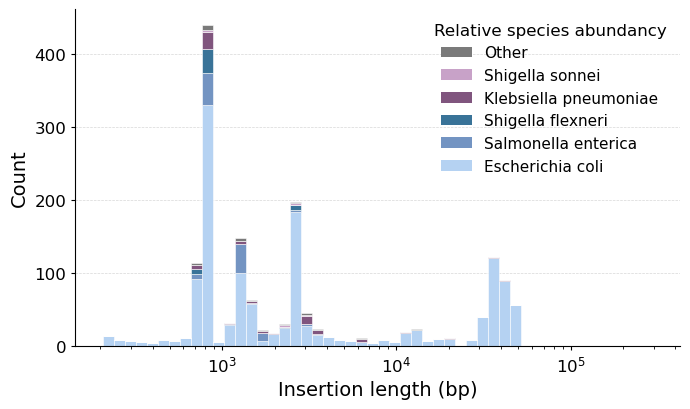

In [41]:
plot_event_length_distribution(
      hits_deduplicated_df,
      #color_by_majority_organism=True,
      color_by_species_counts=True,
      n_species=5,
      log_x=True,
      log_y = False,
      figsize=(7,4.2),
      legend_title="Relative species abundancy",
      save_path="../figures/species_assignments_length.pdf",
      min_length_threshold=None
  )

Saved figure to ../figures/genome_hits_majority_annotation.pdf


(<Figure size 700x420 with 1 Axes>,
 <Axes: xlabel='n. external genomes with hits', ylabel='Count'>)

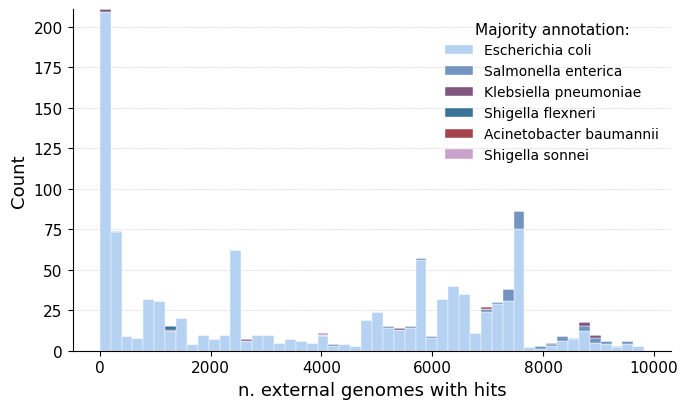

In [16]:
plot_hits_distribution(                                                                                                                                                                                   
    hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] > 0],
    ["n_genomes_external"],                                                                                                                                                                               
    color_by="majority_organism",                                                                                                                                                                       
    bins=50,
    legend_title = "Majority annotation:",
    figsize=(7, 4.2),
    xlabel="n. external genomes with hits",
    save_path="../figures/genome_hits_majority_annotation.pdf"
)

Saved figure to ../figures/n_external_hits.pdf


(<Figure size 700x400 with 1 Axes>, <Axes: ylabel='Count'>)

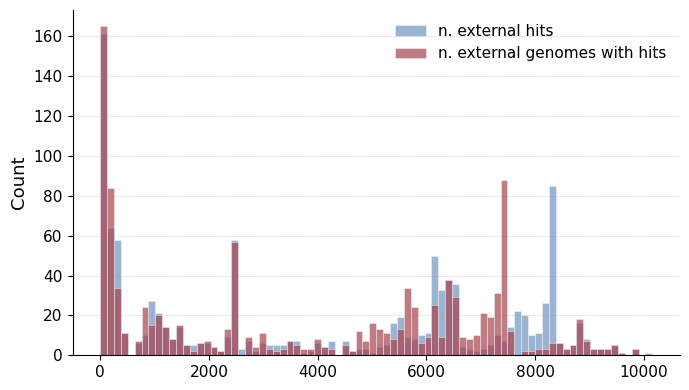

In [44]:
# just say how many are 0
plot_hits_distribution(hits_deduplicated_df[hits_deduplicated_df['n_hits_external']>0], ["n_hits_external", "n_genomes_external"], log_x=False, log_y = False, cumulative=False, bins = 80, legend_labels=["n. external hits", "n. external genomes with hits"], figsize=(7,4), two_colors=True, save_path="../figures/n_external_hits.pdf") 

Saved figure to ../figures/hits_with_species_counts.pdf


(<Figure size 700x400 with 1 Axes>,
 <Axes: xlabel='n. external genomes with hits', ylabel='Count'>)

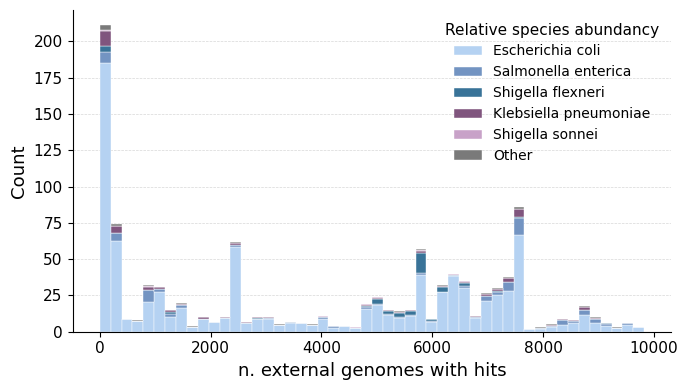

In [45]:
plot_hits_distribution(
      hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] > 0],
      ["n_genomes_external"],
      color_by_species=True,
      n_species=5,
      bins=50,
      legend_title="Relative species abundancy",
      xlabel="n. external genomes with hits",
      figsize = (7,4),
      save_path="../figures/hits_with_species_counts.pdf"
  )

In [20]:
hits_deduplicated_df[hits_deduplicated_df['n_genomes_external'] < 200].majority_organism.value_counts()

majority_organism
Escherichia coli         220
Klebsiella pneumoniae      2
Name: count, dtype: int64

In [16]:
hits_df.n_hits_own_chromosome.value_counts()

n_hits_own_chromosome
0    5713
1    1003
3      13
2       5
Name: count, dtype: int64

In [17]:
hits_df.n_hits_own_plasmid.value_counts()

n_hits_own_plasmid
0    6734
Name: count, dtype: int64

Consider the two consensus paths seperately from each other.

### Consensus 2
There were only 2 insertions found, one short insertion and one long one that we'll now look at in more detail.

In [23]:
insertions_df_2 = insertions_df[insertions_df['consensus'] == 'consensus_2']
insertions_df_2

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx
49,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_2,NZ_AP022171.1,[18228278273347143766|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,820,+,10166,10986,13879318911159590194
50,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_2,NZ_CP098219.1,[2278011600046483881|+|],segment_0,../results/atb_lookup/insertions/CIRMBUYJFK_f_...,37622,+,3488,41110,11400043001338627984


In [11]:
# not annotated as insertion sequence but this is gene content annotation:
#NZ_AP022171.1	GenBank	gene	10173	10694	.	+	.	ID=H7R27_RS10275;Name=ugpC;gene=ugpC;is_partial=False;locus_tag=H7R27_RS10275;pseudo=
#NZ_AP022171.1	GenBank	CDS	10173	10694	.	+	.	ID=H7R27_RS10275;Name=ugpC;codon_start=1;gene=ugpC;inference=COORDINATES: similar to AA sequence:RefSeq:NP_312323.2;is_partial=False;locus_tag=H7R27_RS10275;note=incomplete%3B partial in the middle of a contig%3B missing N-terminus%3B Derived by automated computational analysis using gene prediction method: Protein Homology.;product=sn-glycerol 3-phosphate ABC transporter ATP binding protein UgpC;pseudo=;transl_table=11
#NZ_AP022171.1	GenBank	gene	10691	11008	.	+	.	ID=H7R27_RS10280;Name=H7R27_RS10280;is_partial=False;locus_tag=H7R27_RS10280;old_locus_tag=WP5S18E09_20050;pseudo=
#NZ_AP022171.1	GenBank	CDS	10691	11008	.	+	.	ID=H7R27_RS10280;Name=H7R27_RS10280;go_function=GO:0008081 - phosphoric diester hydrolase activity [Evidence IEA];go_process=GO:0006629 - lipid metabolic process [Evidence IEA];codon_start=1;inference=COORDINATES: similar to AA sequence:RefSeq:NP_709219.1;is_partial=False;locus_tag=H7R27_RS10280;note=incomplete%3B partial in the middle of a contig%3B missing C-terminus%3B Derived by automated computational analysis using gene prediction method: Protein Homology.;old_locus_tag=WP5S18E09_20050;product=glycerophosphodiester phosphodiesterase family protein;pseudo=;transl_table=11
atb_hits_info_df = pd.read_csv("../results/atb_lookup/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus2/NZ_AP022171.1_segment_0.hits_info.tsv", sep = "\t")
atb_hits_info_df.value_counts("organism")

organism
Escherichia coli                  187
Escherichia coli O25b:H4-ST131      4
Acinetobacter baumannii             1
Campylobacter jejuni                1
Escherichia coli KTE216             1
Escherichia coli O13/O135:H4        1
Shigella sonnei                     1
Name: count, dtype: int64

In [12]:
# long insertion: prophage
atb_hits_info_df = pd.read_csv("../results/atb_lookup/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus2/NZ_CP098219.1_segment_0.hits_info.tsv", sep = "\t")
atb_hits_info_df.value_counts("organism")

organism
Escherichia coli                       83
Escherichia coli O145:H28               3
Salmonella enterica                     2
Salmonella enterica subsp. enterica     1
Name: count, dtype: int64

### Consensus 1

In [5]:
# get a list of all blocks that deviate from consensus paths (consider insertions and deletions!)

insertions, deletions, inversions = get_insertions_deletions_from_consensus(assignment_df, consensus_paths, path_dict, consensus = 1)
insertions_df = write_insertions_fasta(example_junction, example_pangraph, insertions, consensus = 1, save_df=True)
# set rerun_alignment to True if deletions are calculated for the first time
deletions_df = summarize_deletions_consensus(deletions, example_junction, example_pangraph, path_dict, assignment_df, consensus_id=1, parent_dir = "../results/atb_lookup/deletions", rerun_alignment=False, save_df=True)

# TODO: now correct fasta files, need to rerun downstream code with correct fasta files
# TODO: moved directory for insertion sequences to ../results/atb_lookup/insertions/, might need to update downstream code

Insertions:
NZ_OX030701.1 INSERTED: [6932368721519041699|-|1314867519434933921_1]
NZ_CP021935.1 INSERTED: [517157241956952768|+|]
NZ_CP076693.1 INSERTED: [964531385716605116|+|]_[16982887268023976258|+|]
NZ_CP128947.1 INSERTED: [964531385716605116|+|]_[16982887268023976258|+|]
NZ_CP107114.1 INSERTED: [517157241956952768|+|]
NZ_CP107172.1 INSERTED: [517157241956952768|+|]
NZ_CP030337.1 INSERTED: [6932368721519041699|+|16056383497489254679_1]
NZ_CP124429.1 INSERTED: [517157241956952768|-|]
NZ_CP018970.1 INSERTED: [6932368721519041699|-|17115477248436968411_1]
NZ_CP019015.1 INSERTED: [16982887268023976258|-|]_[964531385716605116|-|]
NZ_CP124460.1 INSERTED: [964531385716605116|+|]_[16982887268023976258|+|]
NZ_AP022044.1 INSERTED: [6932368721519041699|+|12883103544713419939_1]
NZ_AP022044.1 INSERTED: [6932368721519041699|-|14506298656834147691_1]
NZ_CP103562.1 INSERTED: [7844090243072536214|+|]
NZ_CP051661.1 INSERTED: [6932368721519041699|+|12883103544713419939_1]
NZ_CP051661.1 INSERTED: [6

In [14]:
example_pangraph.blocks[6932368721519041699].alignment.generate_alignment()[str(379839136965539815)]

'GGTAATGACTCCAACTTACTGATAGTGTTTTATGTTCAGATAATGCCCGATGACTTTGTCATGCAGCTCCACCGATTTTGAGAACGACAGTGACTTCCGTCCCAGCCTTGCCAGATGTTGTCTCAGATTCAGGTTATGTCGCTCAATGCGCTGAGTGTAACGCTTGCTGATTACGTGCAGCTTTCCCTTCAGGCGGGATTCATACAGCGGCCAGCCATCCGTCATCCATACCACGACCTCAAAGGCCGACAGCAGGCTCAGAAGACGCTCCAGTGTGGCCAGAGTGCGTTCACCGAAGACGTGCGCCACAACCGTCCTCCGTATCCTGTCATACGCGTAAAACAGCCAGCGCTGACGTGATTTAGCACCGACGTAGCCCCACTGTTCGTCCATTTCAGCGCAGACAATCACATCACTGCCCGGCTGTATGCGCGAGGTTACCGACTGCGGCCTGAGTTTTTTAAGTGACGTAAAATCGTGTTGAGGCCAACGCCCATAATGCGGGCGGTTGCCCGGCATCCAACACCATTCATGGCCATATCAATGATTTTCTGGTGTGTACCGGGTTGAGAAGCGGTGTAAGTGAACTGCAGTTGCCATGTTTTACGGCAGTGAGAGCAGAGATAGCGCTGATGTCCGGCAGTACTTTTACCGTTACGCACCACGCCTTCAGTAGCTGAGCAGGAGGGACAACTGATGGAGATGGAAGCCACGGGAGCACCTCAAAAACACCATCATACACTAAATCAGTAAGTTGGCACCAT----'

In [15]:
example_pangraph.nodes[379839136965539815]

block_id    6932368721519041699
path_id                     123
strand                     True
start                     21143
end                       21907
Name: 379839136965539815, dtype: object

run lexicmap search on cluster for all sequences: bash run_all_lexicmap.sh ./queries/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus1

In [ ]:
# retrieve SAM... to look up in NCBI:
retrieve_SAMids_txt(parent_dir="../results/atb_lookup/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus1")

retrieve info from NCBI: bash fetch_biosamples_consensus1.sh out of this folder results/atb_lookup

In [ ]:
# merge results
combine_NCBI_atb_results(parent_dir="../results/atb_lookup/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus1")

In [141]:
pd.read_csv("../results/atb_lookup/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus1/NZ_CP030337.1_segment_0.ncbi_results.tsv", sep="\t").value_counts('organism')

organism
Campylobacter jejuni         9
Escherichia coli             2
Helicobacter winghamensis    1
Klebsiella pneumoniae        1
Name: count, dtype: int64

In [ ]:
# TODO: should I run blocks seperately or insertions as a whole
# TODO: rerun lexicmap ... now with correctly inverted sequences

Information about different insertion sequences:

- 5 different versions of this block, if a block is twice in one sequence it is always the same version twice, versions can be inserted or not inserted, found between 1 and 9 times in other genomes
    - NZ_CP107151.1, blocks [6932368721519041699|-|]: majority of hits are Mycoplasma mycoides or E. coli and some others, IS1 based on annotation, same insertion in NZ_CP107162.1 and NZ_CP107122.1 blocks [6932368721519041699|-|], same hits, NZ_CP107122.1 even has same insertion a second time[6932368721519041699|+|], NZ_CP128907.1|segment_0 path[6932368721519041699|+|1708810210093552769] length760, NZ_AP022326.1|segment_0 path[6932368721519041699|+|5100696243500885373] length777, NZ_AP022326.1|segment_1 path[6932368721519041699|+|6097212296783908714] length777, NZ_CP124410.1: path[6932368721519041699|+|] IS1, Mycoplasma mycoides and E.coli and Campylobacter jejuni and some more
    - NZ_CP021454.1|segment_0 path[6932368721519041699|-|913783977968963568] length777 and NZ_CP019012.1|segment_0 path[6932368721519041699|-|10145330714100251892] length768 (only found once in genome), inverted, IS1, only 4 hits and different ones --> difference within block!
    - NZ_OX030701.1|segment_0 path[6932368721519041699|-|] length760, NZ_CP018970.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_CP023826.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_LR890693.1|segment_0 path[6932368721519041699|-|11588582069103229002] length760, NZ_CP051661.1|segment_1 path[6932368721519041699|+|10145330714100251892] length776 and segment_0 path[6932368721519041699|+|12883103544713419939] length776, NZ_CP051663.1|segment_0 path[6932368721519041699|+|7987278316461198430] length764, NZ_CP051659.1|segment_0 path[6932368721519041699|+|10145330714100251892] length760, NZ_CP018970.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_CP023826.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_CP124455.1|segment_0 path[6932368721519041699|-|15558722379768673797] length768, same hits, less hits, IS1
    - NZ_CP030337.1|segment_0 path[6932368721519041699|+|16056383497489254679] length760, Campylobacter jejuni version (?)
    - NZ_AP022044.1|segment_0 path[6932368721519041699|+|12883103544713419939] length767 and NZ_AP022044.1|segment_1 path[6932368721519041699|-|14506298656834147691] length767, new version, mostly E.coli, 25 hits

- NZ_CP103562.1: path[7844090243072536214|+|] E. coli and some single different ones, IS3, found twice in genome

- double block: all found twice (once elsewhere in genome), all at same position, just some inverted
    - NZ_CP124374.1 and NZ_CP019015.1: [16982887268023976258|-|]_[964531385716605116|-|] ISL3 (both blogs together): no hits (TODO: change parameters and rerun or run blogs seperately)
    - NZ_CP059130.1 (segment 1), NZ_AP026788.1 and NZ_AP026794.1, [964531385716605116|+|]_[16982887268023976258|+|], NZ_CP124460.1|segment_0 path[964531385716605116|+|]_[16982887268023976258|+|] length1863, NZ_CP027534.1|segment_0 path[964531385716605116|+|]_[16982887268023976258|+|] length1863, NZ_CP128947.1|segment_0 path[964531385716605116|+|]_[16982887268023976258|+|] length1863: ISL3, mostly E.coli, same hits
    - NZ_LR890693.1|segment_1 path[964531385716605116|-|]_[16982887268023976258|-|], NZ_CP010876.1|segment_0 path[964531385716605116|-|]_[16982887268023976258|-|] length1893, (order was inverted here) length1893, this one got hits now, all E.coli (why hits even though sequences don't fit)
- NZ_CP124424.1|segment_0 path[964531385716605116|+|] length1324, exist as partly insertion (only first block), less hits, E.coli and Lelliottia amnigena, ISL3, found twice


- NZ_CP021935.1, NZ_CP059130.1 (segment 0), NZ_CP107114.1 and NZ_CP107172.1 (identical), NZ_CP107114.1, NZ_CP107172, NZ_CP021179.1, NZ_CP018979.1 and NZ_CP124429.1 (inverted): 517157241956952768 IS3, 100% hits in E.coli and in other bacteria, mostly E. coli, all get the same hits, they might differ in a few bases or some bases at ends, inserted at different positions in genome, one has 3 base overhang, apart from that they are completely the same, different amount of hits in genome (between 2 and 7)

- NZ_AP026788.1 and NZ_AP026794.1: path[16556873922195442803|+|] IS1380, E. coli, Klebsiella pneumoniae, Pseudomonas aeruginosa,Salmonella enterica all frequent, many more, twice in genome and both have same hits

- NZ_CP019008.1|segment_0 path[185719230501067033|+|] length4204, NZ_CP133923.1|segment_0 path[185719230501067033|+|] length4204, NZ_CP124467.1|segment_0 path[185719230501067033|+|] length4204, NZ_CP134384.1|segment_0 path[185719230501067033|+|] length4203 (one nucleotide shorter): 200 hits that are all E. coli. all sequences identical, only once in genome


Difference between consensus 1 and consensus 2 in one big prophage according to annotations

Be careful to not confuse context for next block!

In [87]:
pd.read_csv("../results/atb_lookup/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus1/NZ_AP022044.1_segment_0.hits_info.tsv", sep="\t")[["query", "qlen", 'hits', 'sgenome', 'qcovGnm', 'cls', 'hsp',
       'qcovHSP', 'alenHSP', 'pident', 'gaps', 'evalue', 'bitscore', 'organism', 'strain',
       'serovar', 'sequence_type']]

,query,qlen,hits,sgenome,qcovGnm,cls,hsp,qcovHSP,alenHSP,pident,gaps,evalue,bitscore,organism,strain,serovar,sequence_type
0,NZ_AP022044.1|segment_0,767,25,SAMEA4062129,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,NaN,NaN,NaN
1,NZ_AP022044.1|segment_0,767,25,SAMN14049574,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,E. coli QEC12-15,NaN,NaN
2,NZ_AP022044.1|segment_0,767,25,SAMN07508953,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,29-KPC,NaN,NaN
3,NZ_AP022044.1|segment_0,767,25,SAMEA104040230,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,NaN,NaN,NaN
4,NZ_AP022044.1|segment_0,767,25,SAMEA111271919,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,NaN,NaN,NaN
5,NZ_AP022044.1|segment_0,767,25,SAMN08382692,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,GASRECE110,NaN,NaN
6,NZ_AP022044.1|segment_0,767,25,SAMEA111273518,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,NaN,NaN,NaN
7,NZ_AP022044.1|segment_0,767,25,SAMN18977267,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,missing,missing,NaN
8,NZ_AP022044.1|segment_0,767,25,SAMEA111273646,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,NaN,NaN,NaN
9,NZ_AP022044.1|segment_0,767,25,SAMEA111273548,100.0,1,1,100.0,768,99.870,1,0.0,1389,Escherichia coli,NaN,NaN,NaN


In [ ]:
# TODO: do I also search deletions in the database?

'GGTAATGACTCCAACTTACTGATAGTGTTTTATGTTCAGATAATGCCCGATGACTTTGTCATGCAGCTCCACCGATTTTGAGAACGACAGTGACTTCCGTCCCAGCCTTGCCAGATGTTGTCTCAGATTCAGGTTATGTCGCTCAATGCGCTGAGTGTAACGCTTGCTGATTACGTGCAGCTTTCCCTTCAGGCGGGATTCATACAGCGGCCAGCCATCCGTCATCCATACCACGACCTCAAAGGCCGACAGCAGGCTCAGAAGACGCTCCAGTGTGGCCAGAGTGCGTTCACCGAAGACGTGCGCCACAACCGTCCTCCGTATCCTGTCATACGCGTAAAACAGCCAGCGCTGACGTGATTTAGCACCGACGTAGCCCCACTGTTCGTCCATTTCAGCGCAGACAATCACATCACTGCCCGGCTGTATGCGCGAGGTTACCGACTGCGGCCTGAGTTTTTTAAGTGACGTAAAATCGTGTTGAGGCCAACGCCCATAATGCGGGCGGTTGCCCGGCATCCAACACCATTCATGGCCATATCAATGATTTTCTGGTGTGTACCGGGTTGAGAAGCGGTGTAAGTGAACTGCAGTTGCCATGTTTTACGGCAGTGAGAGCAGAGATAGCGCTGATGTCCGGCAGTACTTTTACCGTTACGCACCACGCCTTCAGTAGCTGAGCAGGAGGGACAACTGATGGAGATGGAAGCCACGGGAGCACCTCAAAAACACCATCATACACTAAATCAGTAAGTTGGCA'

## Search insertion sequences in their own genome

In [19]:
# make sure that all genome fasta files exist
#convert_gbk_fasta(gbk_folder = "../data/gbk", fasta_folder = "../results/genome_fastas")

In [ ]:
self_hits = find_insertion_hits_own_genome(genome_root = "../results/genome_fastas", insertions_seq_dir=f"../results/atb_lookup/insertions")

# 17 min

[M::mm_idx_gen::0.075*1.09] collected minimizers
[M::mm_idx_gen::0.085*1.28] sorted minimizers
[M::main::0.085*1.28] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.089*1.26] mid_occ = 50
[M::mm_idx_stat] kmer size: 19; skip: 19; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.094*1.25] distinct minimizers: 492831 (99.37% are singletons); average occurrences: 1.013; average spacing: 9.995; total length: 4988092
[M::worker_pipeline::0.097*1.22] mapped 1 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -x asm5 -N 50 -p 0.9 -k 19 --eqx ../results/genome_fastas/NZ_CP032265.1.fasta ../results/atb_lookup/insertions/CCBTELCMAW_f__XDNOEMXHOO_f/consensus1/NZ_CP032265.1_segment_0.fasta
[M::main] Real time: 0.108 sec; CPU: 0.128 sec; Peak RSS: 0.043 GB
[M::mm_idx_gen::0.072*1.03] collected minimizers
[M::mm_idx_gen::0.086*1.25] sorted minimizers
[M::main::0.086*1.25] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.092*1.23] mid_occ = 50
[M::mm_

In [32]:
self_hits.to_csv("../results/atb_lookup/insertions/self_hits_chromosome.csv", index = False)

In [22]:
self_hits = pd.read_csv("../results/atb_lookup/insertions/self_hits_chromosome.csv")
self_hits.hits_in_genome.value_counts()

hits_in_genome
1     4783
0     1170
4      490
2      426
3      317
5      288
6      185
7      159
8       95
10      72
9       60
13      35
12       4
14       2
17       1
Name: count, dtype: int64

In [30]:
self_hits = self_hits[self_hits['insertion_length'] > 500]

In [32]:
self_hits[self_hits['hits_in_genome'] == 0].value_counts('insertion_length').sum()

np.int64(76)

In [ ]:
plasmid_insertions_df = find_insertion_hits_in_plasmids(plasmid_fasta_root="../results/plasmid_fastas", insertions_seq_dir=f"../results/atb_lookup/insertions")
# 10min

In [3]:
plasmid_insertions_df.to_csv("../results/atb_lookup/insertions/self_hits_plasmids.csv", index=False)

,junction_name,consensus,isolate_name,plasmid_name,insertion_path,insertion_length,segment,hits_in_plasmid
0,CCBTELCMAW_f__XDNOEMXHOO_f,consensus1,NZ_CP032265.1,NZ_CP032264.1,[17187306016188032338|+|],329,segment_0,0
1,CCBTELCMAW_f__XDNOEMXHOO_f,consensus1,NZ_CP032265.1,NZ_CP032263.1,[17187306016188032338|+|],329,segment_0,0
2,CCBTELCMAW_f__XDNOEMXHOO_f,consensus1,NZ_CP014488.1,NZ_CP014489.1,[17187306016188032338|+|],328,segment_0,0
3,CCBTELCMAW_f__XDNOEMXHOO_f,consensus1,NZ_CP014488.1,NZ_CP014490.1,[17187306016188032338|+|],328,segment_0,0
4,CCBTELCMAW_f__XDNOEMXHOO_f,consensus1,NZ_CP014488.1,NZ_CP014491.1,[17187306016188032338|+|],328,segment_0,0
...,...,...,...,...,...,...,...,...
21914,FHCOVEKCDA_f__OOKLAQXFLW_r,consensus1,NZ_CP018991.1,NZ_CP018990.1,[1978294059578033199|+|],1909,segment_0,0
21915,FHCOVEKCDA_f__OOKLAQXFLW_r,consensus1,NZ_CP124424.1,NZ_CP124428.1,[16980716658012760730|+|],1258,segment_0,0
21916,FHCOVEKCDA_f__OOKLAQXFLW_r,consensus1,NZ_CP124424.1,NZ_CP124427.1,[16980716658012760730|+|],1258,segment_0,0
21917,FHCOVEKCDA_f__OOKLAQXFLW_r,consensus1,NZ_CP124424.1,NZ_CP124426.1,[16980716658012760730|+|],1258,segment_0,1


In [4]:
# Quality control, need to have at least 1 hit and need to be longer than 200bp, also subtracts -1 because we only count additional occurences

self_hits = pd.read_csv("../results/atb_lookup/insertions/self_hits_chromosome.csv")
plasmid_insertions_df = pd.read_csv("../results/atb_lookup/insertions/self_hits_plasmids.csv")
self_hits = self_hits[self_hits["insertion_length"] > 200]
self_hits = self_hits[self_hits['hits_in_genome']!=0]
self_hits['hits_in_genome'] = self_hits["hits_in_genome"] - 1
plasmid_summary_df = pd.read_csv("../results/atb_lookup/insertions/self_hits_plasmids.csv")
plasmid_summary_df = plasmid_insertions_df.groupby(["consensus", "isolate_name", "segment"])["hits_in_plasmid"].sum().reset_index()
self_hits = self_hits.merge(
    plasmid_summary_df,
    left_on=["consensus", "genome_name", "segment"],
    right_on=["consensus", "isolate_name", "segment"],
    how="left"
).drop(columns=['isolate_name'])

summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=False)

self_hits['consensus'] = self_hits['consensus'].str.replace('consensus', 'consensus_', regex=False)                                                                                                           

self_hits_merged = summaries['insertions'].merge(                                                                                                                                                                   
      self_hits.rename(columns={"segment": "insertion"}),                                                                                                                                                     
      on=["junction_name", "consensus", "genome_name", "insertion"],                                                                                                                                        
      how="inner"  
  )
self_hits_merged

self_hits_deduplicated_df = deduplicate_events({"insertions": self_hits_merged})
self_hits_deduplicated_df['self_hits'] = self_hits_deduplicated_df['hits_in_genome'] + self_hits_deduplicated_df['hits_in_plasmid']


#insertions_df.sort_values(['consensus','insertion_path'])

In [5]:
self_hits_merged

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx,insertion_path,insertion_length,hits_in_genome,hits_in_plasmid
0,ADIVNXMSJF_r__CGRLRHSCCE_f,consensus_1,NZ_CP103562.1,[10467811667185626553|+|],segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283,15264,12675429639006275041,[10467811667185626553|+|],10981,0,5.0
1,ADOVFNSINA_f__ECOWCWQMQJ_f,consensus_1,NZ_CP116085.1,[2885183895822662185|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189,7966,12863862502596669040,[2885183895822662185|+|],777,5,0.0
2,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_CP107153.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941,12718,16305501466558477249,[6114133947861579624|+|],777,4,6.0
3,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_AP022044.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,6295978535415985145,[6114133947861579624|+|],765,8,3.0
4,AEJQYPEVQR_f__SQYOENFQOY_f,consensus_1,NZ_OX030701.1,[1233050476806559636|-|],segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,2793,3570,3579820473221573810,[1233050476806559636|-|],768,3,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6498,YJSEGEHASG_r__YWSGZOAHNX_r,consensus_1,NZ_CP019012.1,[3886675241220391455|+|],segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,58257,60797,12716710876323799779,[3886675241220391455|+|],2540,4,7.0
6499,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104846.1,[3870718793672684742|+|5120184519711206319_1],segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,60231,60999,5120184519711206319,[3870718793672684742|+|5120184519711206319_1],768,2,4.0
6500,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104848.1,[2624032834068938794|+|]_[1528420688200569391|...,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,60231,180320,5120184519711206319,[2624032834068938794|+|]_[1528420688200569391|...,120075,0,3.0
6501,YVEVUPDYEE_f__ZFYFAGFPQE_f,consensus_1,NZ_CP124436.1,[213612989930417787|+|],segment_0,../results/atb_lookup/insertions/YVEVUPDYEE_f_...,42512,+,8832,51344,2622873865824788133,[213612989930417787|+|],42512,0,3.0


In [52]:
self_hits_deduplicated_df

,event_type,junction_name,path,ctx,consensus,insertion,fasta_path,length,strand,start_pos,end_pos,insertion_path,insertion_length,hits_in_genome,hits_in_plasmid
0,insertion,ADIVNXMSJF_r__CGRLRHSCCE_f,[10467811667185626553|+|],12675429639006275041,consensus_1,segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283,15264,[10467811667185626553|+|],10981,0,5
1,insertion,ADOVFNSINA_f__ECOWCWQMQJ_f,[2885183895822662185|+|],12863862502596669040,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189,7966,[2885183895822662185|+|],777,5,0
2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],6295978535415985145,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,[6114133947861579624|+|],765,8,3
3,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],16305501466558477249,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941,12718,[6114133947861579624|+|],777,4,6
4,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|+|],13278839926153538614,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,776,+,2502,3278,[1233050476806559636|+|],776,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,insertion,XXVQEZNBQB_f__YMBQLXNBIS_f,[7798500702088635138|+|],7460938438515399510,consensus_2,segment_0,../results/atb_lookup/insertions/XXVQEZNBQB_f_...,1309,+,7938,9247,[7798500702088635138|+|],1309,5,3
1723,insertion,YJSEGEHASG_r__YWSGZOAHNX_r,[3886675241220391455|+|],12716710876323799779,consensus_1,segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,58257,60797,[3886675241220391455|+|],2540,4,7
1724,insertion,YUOECYBHUS_f__ZTHKZYHPIX_f,[2624032834068938794|+|]_[1528420688200569391|...,5120184519711206319,consensus_1,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,60231,180320,[2624032834068938794|+|]_[1528420688200569391|...,120075,0,3
1725,insertion,YUOECYBHUS_f__ZTHKZYHPIX_f,[3870718793672684742|+|5120184519711206319_1],5120184519711206319,consensus_1,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,60231,60999,[3870718793672684742|+|5120184519711206319_1],768,2,4


In [55]:
self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_plasmid'] > 0) & (self_hits_deduplicated_df['hits_in_genome'] > 0)]

,event_type,junction_name,path,ctx,consensus,insertion,fasta_path,length,strand,start_pos,end_pos,insertion_path,insertion_length,hits_in_genome,hits_in_plasmid,self_hits
2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],6295978535415985145,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,[6114133947861579624|+|],765,8,3,11
3,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],16305501466558477249,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941,12718,[6114133947861579624|+|],777,4,6,10
4,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|+|],13278839926153538614,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,776,+,2502,3278,[1233050476806559636|+|],776,1,6,7
5,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|-|],3579820473221573810,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,2793,3570,[1233050476806559636|-|],768,3,32,35
6,insertion,AEJQYPEVQR_r__OCLLBLOTSW_r,[17196936016257344825|+|],1770589709192440149,consensus_1,segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_r_...,776,+,2494,3270,[17196936016257344825|+|],776,3,10,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[8965990111567368033|-|17687220482716050848_1]...,17687220482716050848,consensus_1,segment_0,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,768,-,14449,15225,[8965990111567368033|-|17687220482716050848_1]...,768,7,7,14
1719,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[8965990111567368033|-|553046064951206748_1]_[...,553046064951206748,consensus_1,segment_2,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,768,-,126607,127384,[8965990111567368033|-|553046064951206748_1]_[...,768,9,2,11
1722,insertion,XXVQEZNBQB_f__YMBQLXNBIS_f,[7798500702088635138|+|],7460938438515399510,consensus_2,segment_0,../results/atb_lookup/insertions/XXVQEZNBQB_f_...,1309,+,7938,9247,[7798500702088635138|+|],1309,5,3,8
1723,insertion,YJSEGEHASG_r__YWSGZOAHNX_r,[3886675241220391455|+|],12716710876323799779,consensus_1,segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,58257,60797,[3886675241220391455|+|],2540,4,7,11


In [46]:
self_hits_deduplicated_df.hits_in_genome.value_counts()

hits_in_genome
0     769
3     195
4     156
1     143
2     139
5      93
6      71
7      56
9      39
12     33
8      29
11      4
Name: count, dtype: int64

Saved figure to ../figures/n_hits_chromosome_plasmid_seperate.pdf


(<Figure size 700x400 with 1 Axes>, <Axes: ylabel='Count'>)

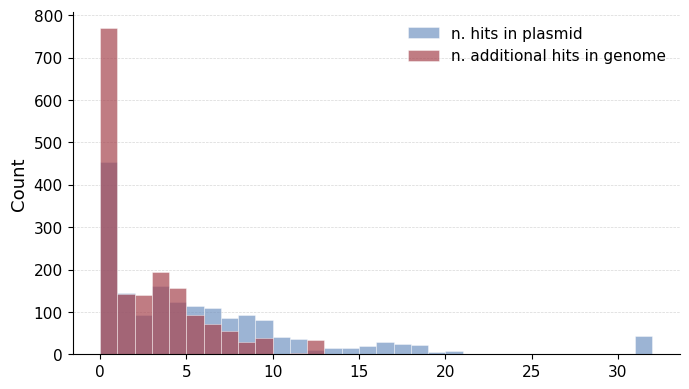

In [6]:
plot_hits_distribution(self_hits_deduplicated_df, ["hits_in_plasmid","hits_in_genome"], bin_width = 1, log_x=False, log_y = False, cumulative=False, legend_labels=["n. hits in plasmid", "n. additional hits in genome"], figsize=(7,4), two_colors=True, stacked= False, save_path="../figures/n_hits_chromosome_plasmid_seperate.pdf") 

Saved figure to ../figures/n_hits_chromosome_plasmid.pdf


(<Figure size 700x400 with 1 Axes>,
 <Axes: xlabel='n. hits in chromosome or plasmids', ylabel='Count'>)

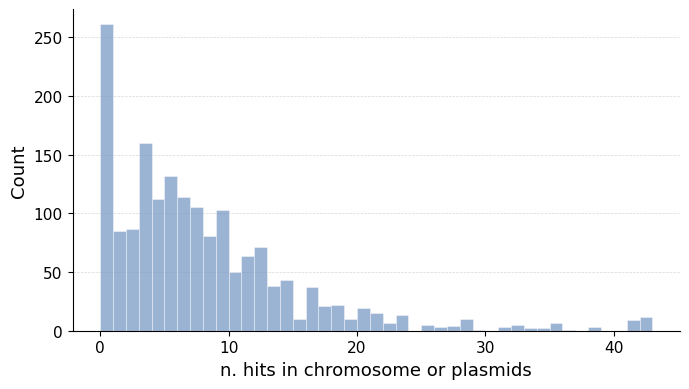

In [32]:
plot_hits_distribution(self_hits_deduplicated_df, ["self_hits"], bin_width = 1, log_x=False, log_y = False, cumulative=False, xlabel = "n. hits in chromosome or plasmids", figsize=(7,4), two_colors=True, stacked= False, save_path="../figures/n_hits_chromosome_plasmid.pdf") 